# Обучение YOLOv8n для детекции номеров на датасете SVHN

Этот notebook выполняет:
1. Загрузку и подготовку датасета SVHN
2. Конвертацию аннотаций в формат YOLO
3. Обучение модели YOLOv8n
4. Оценку качества на тестовой выборке (IoU, Precision, Recall, mAP)

Требуется: mAP@0.5 не менее 0.6

In [7]:
!pip install ultralytics scipy h5py pillow matplotlib opencv-python pyyaml -q

In [8]:
import os
import urllib.request
import tarfile
import h5py
import numpy as np
from PIL import Image
import cv2
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
from ultralytics import YOLO
import yaml
import json

## 1. Загрузка датасета SVHN

In [9]:
data_dir = Path('/content/sample_data/svhn_data')

(data_dir / 'train').mkdir(exist_ok=True)
(data_dir / 'test').mkdir(exist_ok=True)

urls = {
    'train': 'http://ufldl.stanford.edu/housenumbers/train.tar.gz',
    'test': 'http://ufldl.stanford.edu/housenumbers/test.tar.gz'
}

print('Примечание: файлы digitStruct.mat будут извлечены из tar.gz архивов')
print('После распаковки они будут доступны в:')
print(f'  - {data_dir}/train/digitStruct.mat')
print(f'  - {data_dir}/test/digitStruct.mat')

Примечание: файлы digitStruct.mat будут извлечены из tar.gz архивов
После распаковки они будут доступны в:
  - /content/sample_data/svhn_data/train/digitStruct.mat
  - /content/sample_data/svhn_data/test/digitStruct.mat


In [10]:
def download_file(url, output_path):
    if not os.path.exists(output_path):
        print(f'Загрузка {url}...')
        urllib.request.urlretrieve(url, output_path)
        print(f'Сохранено в {output_path}')
    else:
        print(f'Файл {output_path} уже существует')

def extract_tar(tar_path, extract_path):
      print(f'Распаковка {tar_path}...')
      with tarfile.open(tar_path, 'r:gz') as tar:
          tar.extractall(extract_path)
      print(f'Распаковано в {extract_path}')

train_tar = data_dir / 'train.tar.gz'
if not train_tar.exists():
    download_file(urls['train'], train_tar)
extract_tar(train_tar, data_dir)

test_tar = data_dir / 'test.tar.gz'
if not test_tar.exists():
    download_file(urls['test'], test_tar)
extract_tar(test_tar, data_dir)

train_mat = data_dir / 'train' / 'digitStruct.mat'
test_mat = data_dir / 'test' / 'digitStruct.mat'

Загрузка http://ufldl.stanford.edu/housenumbers/train.tar.gz...
Сохранено в /content/sample_data/svhn_data/train.tar.gz
Распаковка /content/sample_data/svhn_data/train.tar.gz...


/tmp/ipykernel_4552/465975521.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Распаковано в /content/sample_data/svhn_data
Загрузка http://ufldl.stanford.edu/housenumbers/test.tar.gz...
Сохранено в /content/sample_data/svhn_data/test.tar.gz
Распаковка /content/sample_data/svhn_data/test.tar.gz...
Распаковано в /content/sample_data/svhn_data

✓ Файлы digitStruct.mat успешно извлечены:
  Train: /content/sample_data/svhn_data/train/digitStruct.mat
  Test: /content/sample_data/svhn_data/test/digitStruct.mat


## 2. Парсинг аннотаций digitStruct.mat

In [11]:
def parse_digit_struct(mat_path):
    import h5py

    annotations = []

    with h5py.File(mat_path, 'r') as f:
        digit_struct = f['digitStruct']

        name_dataset = digit_struct['name']
        bbox_dataset = digit_struct['bbox']

        num_images = len(name_dataset)
        print(f"Всего изображений в файле: {num_images}")

        for i in range(num_images):
            name_ref = name_dataset[i][0]
            name_obj = f[name_ref]
            name = ''.join(chr(c[0]) for c in name_obj[:])

            bbox_ref = bbox_dataset[i][0]
            bbox = f[bbox_ref]

            height_ref = bbox['height']
            width_ref = bbox['width']
            top_ref = bbox['top']
            left_ref = bbox['left']
            label_ref = bbox['label']

            if len(height_ref.shape) > 0 and height_ref.shape[0] > 1:
                num_digits = height_ref.shape[0]
                heights = [float(f[height_ref[j][0]][0][0]) for j in range(num_digits)]
                widths = [float(f[width_ref[j][0]][0][0]) for j in range(num_digits)]
                tops = [float(f[top_ref[j][0]][0][0]) for j in range(num_digits)]
                lefts = [float(f[left_ref[j][0]][0][0]) for j in range(num_digits)]
                labels = [int(f[label_ref[j][0]][0][0]) for j in range(num_digits)]
            else:
                num_digits = 1
                if isinstance(height_ref[0], h5py.Reference):
                    heights = [float(f[height_ref[0]][0][0])]
                    widths = [float(f[width_ref[0]][0][0])]
                    tops = [float(f[top_ref[0]][0][0])]
                    lefts = [float(f[left_ref[0]][0][0])]
                    labels = [int(f[label_ref[0]][0][0])]
                else:
                    heights = [float(height_ref[0])]
                    widths = [float(width_ref[0])]
                    tops = [float(top_ref[0])]
                    lefts = [float(left_ref[0])]
                    labels = [int(label_ref[0])]

            boxes = []
            for j in range(num_digits):
                label = labels[j]
                if label == 10:
                    label = 0

                boxes.append({
                    'label': label,
                    'height': heights[j],
                    'width': widths[j],
                    'top': tops[j],
                    'left': lefts[j]
                })

            annotations.append({
                'filename': name,
                'boxes': boxes
            })

    return annotations

train_annotations = parse_digit_struct(data_dir / 'train/digitStruct.mat')
test_annotations  = parse_digit_struct(data_dir / 'test/digitStruct.mat')


Всего изображений в файле: 33402


/tmp/ipykernel_4552/1989537201.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  heights = [float(height_ref[0])]
/tmp/ipykernel_4552/1989537201.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  widths = [float(width_ref[0])]
/tmp/ipykernel_4552/1989537201.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tops = [float(top_ref[0])]
/tmp/ipykernel_4552/1989537201.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and 

Всего изображений в файле: 13068


## 3. Конвертация аннотаций в формат YOLO

In [12]:
def convert_to_yolo_format(annotations, images_dir, output_dir, split_name):
    output_dir = Path(output_dir)
    images_output = output_dir / 'images' / split_name
    labels_output = output_dir / 'labels' / split_name

    images_output.mkdir(parents=True, exist_ok=True)
    labels_output.mkdir(parents=True, exist_ok=True)

    for ann in annotations:
        filename = ann['filename']
        boxes = ann['boxes']

        src_image_path = Path(images_dir) / filename
        dst_image_path = images_output / filename

        if not src_image_path.exists():
            continue

        shutil.copy(src_image_path, dst_image_path)

        img = Image.open(src_image_path)
        img_width, img_height = img.size

        if len(boxes) == 0:
            continue

        min_left = min(b['left'] for b in boxes)
        min_top = min(b['top'] for b in boxes)
        max_right = max(b['left'] + b['width'] for b in boxes)
        max_bottom = max(b['top'] + b['height'] for b in boxes)

        total_width = max_right - min_left
        total_height = max_bottom - min_top

        x_center = (min_left + total_width / 2) / img_width
        y_center = (min_top + total_height / 2) / img_height
        width = total_width / img_width
        height = total_height / img_height

        x_center = max(0, min(1, x_center))
        y_center = max(0, min(1, y_center))
        width = max(0, min(1, width))
        height = max(0, min(1, height))

        label_content = f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n"

        label_filename = Path(filename).stem + '.txt'
        with open(labels_output / label_filename, 'w') as f:
            f.write(label_content)

    print(f"{split_name}: {len(list(images_output.glob('*.png')))} изображений, {len(list(labels_output.glob('*.txt')))} аннотаций")

convert_to_yolo_format(
    train_annotations,
    data_dir / 'train',
    'yolo_data',
    'train'
)

convert_to_yolo_format(
    test_annotations,
    data_dir / 'test',
    'yolo_data',
    'test'
)

train: 33402 изображений, 33402 аннотаций
test: 13068 изображений, 13068 аннотаций


In [13]:
data_yaml = {
    'path': str(Path('yolo_data').absolute()),
    'train': 'images/train',
    'val': 'images/test',
    'test': 'images/test',
    'nc': 1,
    'names': ['number']
}

with open('yolo_data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("Конфигурация YOLO сохранена в yolo_data.yaml")
print(yaml.dump(data_yaml, default_flow_style=False))

Конфигурация YOLO сохранена в yolo_data.yaml
names:
- number
nc: 1
path: /content/yolo_data
test: images/test
train: images/train
val: images/test



## 4. Визуализация примеров

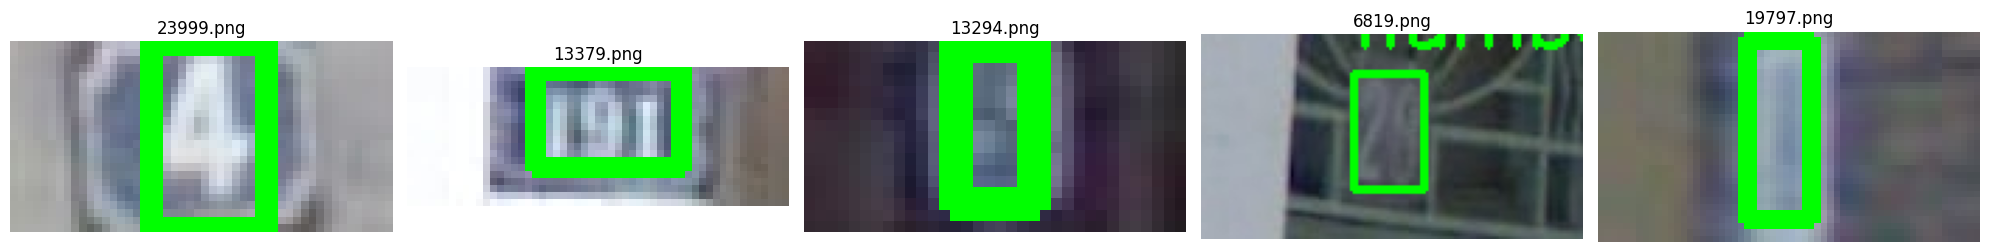

In [14]:
def visualize_yolo_annotation(image_path, label_path):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    with open(label_path, 'r') as f:
        line = f.readline().strip()

    parts = line.split()
    x_center, y_center, width, height = map(float, parts[1:])

    x1 = int((x_center - width/2) * w)
    y1 = int((y_center - height/2) * h)
    x2 = int((x_center + width/2) * w)
    y2 = int((y_center + height/2) * h)

    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img, 'number', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    return img

train_images = list(Path('yolo_data/images/train').glob('*.png'))[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, img_path in enumerate(train_images):
    label_path = Path('yolo_data/labels/train') / (img_path.stem + '.txt')
    if label_path.exists():
        viz_img = visualize_yolo_annotation(img_path, label_path)
        axes[i].imshow(viz_img)
        axes[i].set_title(img_path.name)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

## 5. Обучение YOLOv8n

In [15]:
model = YOLO('yolov8n.pt')

print("Модель YOLOv8n загружена")
print(f"Количество классов: {model.model.nc}")

Модель YOLOv8n загружена
Количество классов: 80


In [16]:
results = model.train(
    data='yolo_data.yaml',
    epochs=5,
    imgsz=640,
    batch=64,
    patience=20,
    device='0',
    workers=8,
    pretrained=True,
    optimizer='Adam',
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    box=7.5,
    cls=0.5,
    dfl=1.5,
    label_smoothing=0.1,
    nbs=64,
    overlap_mask=True,
    val=True,
    plots=True,
    save=True,
    project='svhn_training',
    name='yolov8n_svhn'
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_svhn, nbs=64, nms=False, opset=None, optimize=

## 6. Оценка качества модели

In [ ]:
best_model = YOLO('/content/runs/detect/svhn_training/yolov8n_svhn/weights/best.pt')

metrics = best_model.val(
    data='yolo_data.yaml',
    split='test',
    save_json=True,
    save_hybrid=True,
    conf=0.001,
    iou=0.6
)

WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 824.9±784.3 MB/s, size: 15.3 KB)
val: Scanning /content/yolo_data/labels/test.cache... 13068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13068/13068 4.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 71% ━━━━━━━━──── 576/817 10.2it/s 1:19<23.6s

In [25]:
print(f"\nIoU (Intersection over Union):")
print(f"  mAP@0.5:     {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {metrics.box.map:.4f}")


print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall:    {metrics.box.mr:.4f}")


print(f"\nПодробные метрики:")
print(f"  mAP50-95: {metrics.box.map:.4f}")
print(f"  mAP50:    {metrics.box.map50:.4f}")
print(f"  mAP75:    {metrics.box.map75:.4f}")


IoU (Intersection over Union):
  mAP@0.5:     0.9197
  mAP@0.5:0.95: 0.5295
  Precision: 0.8949
  Recall:    0.8851

Подробные метрики:
  mAP50-95: 0.5295
  mAP50:    0.9197
  mAP75:    0.5557


## 8. Тестирование на примерах из тестовой выборки


image 1/1 /content/yolo_data/images/test/6819.png: 320x640 2 numbers, 13.8ms
Speed: 2.4ms preprocess, 13.8ms inference, 2.2ms postprocess per image at shape (1, 3, 320, 640)

image 1/1 /content/yolo_data/images/test/12068.png: 256x640 1 number, 13.2ms
Speed: 2.2ms preprocess, 13.2ms inference, 1.9ms postprocess per image at shape (1, 3, 256, 640)

image 1/1 /content/yolo_data/images/test/2935.png: 352x640 1 number, 7.7ms
Speed: 1.2ms preprocess, 7.7ms inference, 1.2ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/yolo_data/images/test/3806.png: 192x640 1 number, 6.6ms
Speed: 1.4ms preprocess, 6.6ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 640)

image 1/1 /content/yolo_data/images/test/1703.png: 320x640 1 number, 7.9ms
Speed: 1.4ms preprocess, 7.9ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

image 1/1 /content/yolo_data/images/test/1245.png: 320x640 1 number, 5.8ms
Speed: 1.1ms preprocess, 5.8ms inference, 1.1ms postproces

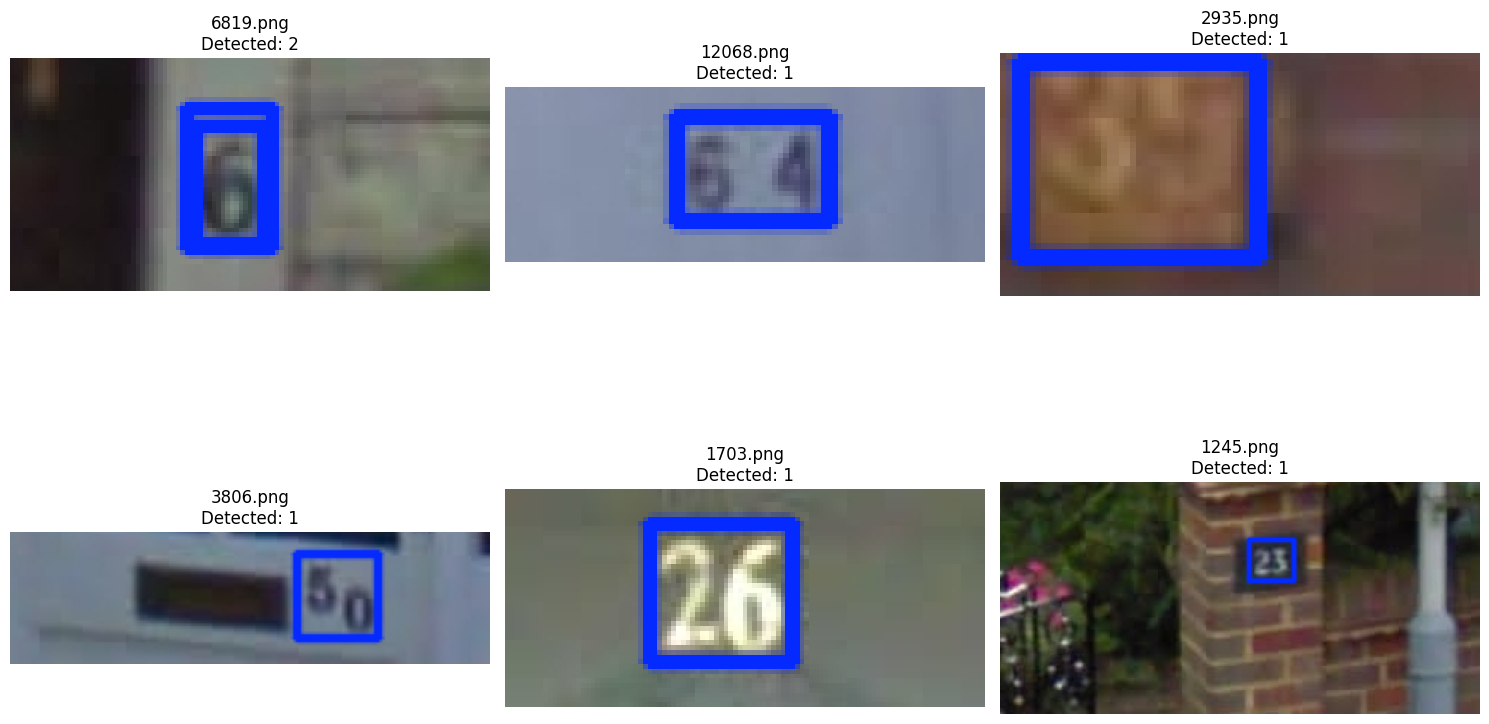

In [26]:
test_images = list(Path('yolo_data/images/test').glob('*.png'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, img_path in enumerate(test_images):
    results = best_model(str(img_path), conf=0.25)

    for r in results:
        im_array = r.plot(labels=False, conf=False)
        axes[i].imshow(im_array[..., ::-1])
        axes[i].set_title(f"{img_path.name}\nDetected: {len(r.boxes)}")
        axes[i].axis('off')

plt.tight_layout()
plt.show()